## Project 1

For your first project, you are asked to

*   Identify and load a network dataset that has some categorical information available for each node.
*   For each of the nodes in the dataset, calculate degree centrality and eigenvector centrality.
*   Compare your centrality measures across your categorical groups.

For example, using the dataset from a study of romantic relationships among high school students in Columbus, Ohio [https://web.archive.org/web/20170526072109/https://researchnews.osu.edu/archive/chains.htm], you might want to determine if there are any differences in your calculated centrality measures between the two sexes.  You might use a t-test or another statistical measure to support your findings.

Your project should be delivered in an Jupyter Notebook, and posted in GitHub.  Your project is due end of day Monday. You and your team should created a video presentation about your project. You should be ready to present your project in our Meet-up on Thursday.

### Introduction

In this project, I will analyze the Hospital Ward Dynamic Contact Network from SocioPatterns, which records face-to-face interactions among healthcare workers and patients in a hospital ward in Lyon, France. The dataset includes information about the individuals involved in each interaction and their roles, including nurses, medical doctors, administrative staff, and patients. I will construct a network in which each individual represents a node and interactions between individuals represent edges. This network will allow me to examine how individuals' positions within the network vary across different hospital roles.

I will calculate degree centrality and eigenvector centrality for each individual and compare these measures across the four role categories. Degree centrality measures the number of direct connections an individual has within the network, while eigenvector centrality measures whether an individual is connected to other highly connected individuals. I will use ANOVA and Tukey HSD to determine whether there are differences in centrality between the groups. The goal of this analysis is to understand whether an individual's role in the hospital is associated with their position within the contact network.

I hypothesize that individuals with different roles in the hospital will have different levels of degree centrality. Specifically, I expect nurses and nurses' aides to have higher average degree centrality than patients because they are likely to have direct contact with multiple patients as well as other healthcare workers throughout their shifts. I also expect medical doctors to have relatively high degree centrality because they interact with both patients and other healthcare staff, although I predict that their average degree centrality will be lower than that of nurses and nurses' aides. Patients, on the other hand, are expected to have fewer direct connections because their interactions may involve a smaller number of healthcare workers and other individuals. Administrative staff may have varying levels of centrality depending on their specific responsibilities and how frequently they interact with patients and medical staff.

For eigenvector centrality, I expect a similar pattern, with nurses and nurses' aides potentially having higher scores because they may be connected to many other highly connected healthcare workers and patients. However, eigenvector centrality may reveal differences that are not apparent from degree centrality alone because it considers the centrality of an individual's connections.

#### Install and import the tools

In this section, I import the libraries needed to complete the network analysis. Pandas will be used to load, organize, and manipulate the dataset, while NumPy will support numerical calculations. NetworkX will be used to construct the contact network and calculate network measures such as degree centrality and eigenvector centrality. Matplotlib will be used to create visualizations of the network and the results. I will also use SciPy to conduct statistical tests, including ANOVA, and statsmodels to perform Tukey's HSD post-hoc tests to determine which groups differ from one another.

In [1]:
# Install libraries
#!pip install networkx pandas matplotlib
#!pip install scipy

# Import libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#### Load and preview the data set

The hospital contact dataset was loaded directly from SocioPatterns. Each row represents a recorded interaction between two individuals, with information about the time of the interaction, the two individuals involved, and their respective roles. After loading the data, I check the dimensions, column names, data types, and missing values to make sure the dataset was imported correctly. I also identify the number of unique individuals and the different roles represented in the network.

The output shows that the dataset contains 32,424 recorded interactions across five variables: time, the two individuals involved in each interaction, and their respective roles. There are 75 unique individuals in the network, which matches the 46 healthcare workers and 29 patients described by the SocioPatterns study. The dataset contains no missing values, meaning all recorded interactions have information for the time, individuals, and roles involved.

The four distinct roles are medical doctors (MED), nurses (NUR), administrative staff (ADM), and patients (PAT). These categorical roles will be used later in the analysis to compare degree centrality and eigenvector centrality across groups.

In [2]:
# Load the hospital contact data
url = "https://sociopatterns.org/assets/data/hospital_lyon_contacts.dat.gz"

hosp = pd.read_csv(
    url,
    sep=r"\s+",
    compression="gzip",
    header=None,
    names=["time", "person1", "person2", "role1", "role2"]
)

# Preview rows
hosp.head()

# Check dimensions
print("Shape:", hosp.shape)
print("\nColumns:")

# Check column names, data types, and non-nulls
print("\nColumns:")
print(hosp.columns.tolist())
print("\nDataset information:")
print(hosp.info())

# Check for missing values
print("\nMissing values:")
print(hosp.isnull().sum())

# Number of unique people
people = set(hosp["person1"]) | set(hosp["person2"])
print("Number of unique people:", len(people))

# Check the roles
print("\nroles:")
print(hosp["role1"].unique())
print(hosp["role2"].unique())

# Create a table containing each person and their role
people_roles = pd.concat([
    hosp[["person1", "role1"]].rename(columns={"person1": "person", "role1": "role"}),
    hosp[["person2", "role2"]].rename(columns={"person2": "person", "role2": "role"})
])

people_roles = people_roles.drop_duplicates()
people_per_category = (
    people_roles
    .groupby("role")["person"]
    .nunique()
    .sort_index())

print("\nNumber of people per category:")
print(people_per_category)


Shape: (32424, 5)

Columns:

Columns:
['time', 'person1', 'person2', 'role1', 'role2']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   time     32424 non-null  int64 
 1   person1  32424 non-null  int64 
 2   person2  32424 non-null  int64 
 3   role1    32424 non-null  object
 4   role2    32424 non-null  object
dtypes: int64(3), object(2)
memory usage: 1.2+ MB
None

Missing values:
time       0
person1    0
person2    0
role1      0
role2      0
dtype: int64
Number of unique people: 75

roles:
['MED' 'NUR' 'ADM' 'PAT']
['ADM' 'MED' 'NUR' 'PAT']

Number of people per category:
role
ADM     8
MED    11
NUR    27
PAT    29
Name: person, dtype: int64


### Constructing the network

To analyze the hospital interactions as a social network, I converted the contact data into an undirected graph using NetworkX. Each individual is represented as a node, and their hospital role is stored as a node attribute. An edge is added between two individuals when the dataset records at least one contact between them. Because the network is undirected, the direction of an interaction is not considered; instead, an interaction between two people represents a connection between both individuals.

The resulting network contains 75 nodes and 1,139 edges. The 75 nodes represent the unique individuals in the dataset: 29 patients, 27 nurses, 11 medical doctors, and 8 administrative staff members. These counts add up to all 75 individuals and confirm that each individual has been assigned one of the four roles.

The 1,139 edges represent unique connections between individuals who had at least one recorded contact during the observation period. Although the original dataset contains 32,424 recorded interactions, multiple interactions between the same pair of individuals are represented by a single edge. Therefore, the number of edges is much smaller than the number of interaction records. This creates a network based on whether individuals had contact with one another, rather than how frequently they interacted. As a result, degree centrality measures the number of unique people each individual was connected to, which is the basis for comparing centrality across the four hospital roles.

In [ ]:
# Create an undirected network
G = nx.Graph()

# Create a lookup table for each person's role
person_roles = {}

for _, row in hosp.iterrows():
    person_roles[row["person1"]] = row["role1"]
    person_roles[row["person2"]] = row["role2"]

# Add people as nodes with their role as an attribute
for person, role in person_roles.items():
    G.add_node(person, role=role)

# Add edges between people who had contact
for _, row in hosp.iterrows():
    G.add_edge(row["person1"], row["person2"])

# Check the size of the network
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Check the roles stored in the network
print(nx.get_node_attributes(G, "role"))

from collections import Counter
role_counts = Counter(nx.get_node_attributes(G, "role").values())
print(role_counts)


Number of nodes: 75
Number of edges: 1139
{1157: 'MED', 1232: 'ADM', 1191: 'MED', 1159: 'MED', 1144: 'MED', 1152: 'MED', 1105: 'NUR', 1295: 'NUR', 1109: 'NUR', 1114: 'NUR', 1115: 'NUR', 1098: 'ADM', 1181: 'NUR', 1164: 'NUR', 1116: 'NUR', 1193: 'NUR', 1142: 'NUR', 1149: 'NUR', 1179: 'ADM', 1168: 'MED', 1196: 'NUR', 1365: 'PAT', 1320: 'PAT', 1363: 'PAT', 1374: 'PAT', 1393: 'PAT', 1190: 'NUR', 1261: 'NUR', 1378: 'PAT', 1305: 'PAT', 1352: 'PAT', 1377: 'PAT', 1130: 'MED', 1148: 'MED', 1383: 'PAT', 1327: 'PAT', 1323: 'PAT', 1391: 'PAT', 1399: 'PAT', 1395: 'PAT', 1238: 'NUR', 1246: 'NUR', 1332: 'PAT', 1207: 'NUR', 1373: 'PAT', 1210: 'NUR', 1245: 'NUR', 1100: 'NUR', 1108: 'NUR', 1260: 'MED', 1209: 'ADM', 1307: 'PAT', 1221: 'MED', 1205: 'NUR', 1202: 'NUR', 1362: 'PAT', 1385: 'PAT', 1658: 'ADM', 1702: 'PAT', 1660: 'MED', 1769: 'PAT', 1701: 'PAT', 1401: 'PAT', 1625: 'NUR', 1416: 'PAT', 1613: 'NUR', 1485: 'NUR', 1460: 'PAT', 1535: 'ADM', 1525: 'ADM', 1469: 'PAT', 1547: 'PAT', 1784: 'PAT', 1629: 'N

#### Degree centrality

Degree centrality measures how well connected an individual is within the network. In this analysis, the degree of each person represents the number of unique individuals they had contact with during the observation period. Degree centrality standardizes this measure based on the total number of other individuals in the network, allowing individuals to be compared based on the proportion of possible connections they have.

I calculated degree and degree centrality for all 75 individuals, then ranked the individuals by degree centrality to identify the most connected people in the network. Then I calculated the average degree centrality for each role group to examine whether connectivity differs between nurses, medical doctors, administrative staff, and patients.

The degree centrality results show considerable variation in how connected individuals are within the hospital network. The individual with the highest degree centrality was person 1098, an administrative staff member, with connections to 61 of the other 74 individuals in the network, resulting in a degree centrality of 0.824. The remaining individuals in the top 10 included mostly nurses, but also medical doctors and administrative staff. No patients appeared among the 10 individuals with the highest degree centrality.

When average degree centrality is compared across roles, nurses had the highest average degree centrality at 0.528, followed by medical doctors at 0.480, administrative staff at 0.394, and patients at 0.279. This suggests that, on average, nurses had more unique connections within the network than the other role groups, while patients had fewer. However, these are descriptive differences and do not establish whether the differences between groups are statistically significant. Statistical testing will be used later to determine whether the observed differences are likely to reflect meaningful differences between the role groups.

In [ ]:
# Calculate degree
degree = dict(G.degree())

# Calculate degree centrality for each person
degree_centrality = nx.degree_centrality(G)

# Create a dataframe with the centrality
centrality = pd.DataFrame({
    "person": list(G.nodes()),
    "role": [G.nodes[node]["role"] for node in G.nodes()],
    "degree": [degree[node] for node in G.nodes()],
    "degree_centrality": [degree_centrality[node] for node in G.nodes()]
})

# Sort by degree centrality
centrality = centrality.sort_values(
    "degree_centrality",
    ascending=False)

# Display the top 10 most connected people (individuals with the highest degree centrality)
display(centrality.head(10))

# Average degree centrality by role
role_centrality = (
    centrality
    .groupby("role")["degree_centrality"]
    .mean()
    .sort_values(ascending=False))

print("Average degree centrality by role:")
display(role_centrality)


,person,role,degree,degree_centrality
11,1098,ADM,61,0.824324
15,1193,NUR,58,0.783784
10,1115,NUR,57,0.770270
13,1164,NUR,57,0.770270
45,1210,NUR,56,0.756757
7,1295,NUR,56,0.756757
8,1109,NUR,55,0.743243
0,1157,MED,53,0.716216
57,1658,ADM,51,0.689189
4,1144,MED,50,0.675676


Average degree centrality by role:


,degree_centrality
role,
NUR,0.528028
MED,0.480344
ADM,0.393581
PAT,0.279124


#### Eigenvector centrality

Eigenvector centrality measures an individual's importance based not only on the number of connections they have, but also on the importance of the people they are connected to. In other words, an individual can have a relatively high eigenvector centrality if they are connected to other individuals who are themselves highly connected within the network.

I calculated eigenvector centrality for each of the 75 individuals and added the results to the existing centrality table. I then calculated the average degree and eigenvector centrality for each hospital role. Comparing these two measures allows me to examine whether the roles that tend to have more direct connections also tend to be connected to other highly connected individuals.

The eigenvector centrality results show a pattern similar to the degree centrality results. Person 1098, an administrative staff member, had the highest eigenvector centrality at 0.190, in addition to having the highest degree centrality in the network. Several nurses also had relatively high eigenvector centrality scores, with values above 0.18. Like we saw in degree centrality, no patients were among the 10 individuals with the highest centrality scores.

When the centrality measures are compared by role, nurses had the highest average eigenvector centrality (0.129), followed by medical doctors (0.124), administrative staff (0.101), and patients (0.078). This pattern is consistent with the degree centrality results, suggesting that nurses not only tend to have more direct connections, but their connections also tend to include individuals who are relatively well connected themselves. Therefore, nurses tend to be more connected, and they also tend to be connected to other well-connected people. Patients have the lowest average values for both measures, indicating that they generally occupy less connected positions within the network. These findings are descriptive, however, and statistical testing is still needed to determine whether the differences between roles are statistically significant.

In [ ]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000)

# Add eigenvector centrality to the existing table
centrality["eigenvector_centrality"] = [
    eigenvector_centrality[node]
    for node in centrality["person"]
]

# Display the results
display(centrality.head(10))

# Compare centrality measures by role
role_comparison = (
    centrality
    .groupby("role")[["degree_centrality", "eigenvector_centrality"]]
    .mean())

print("Average centrality measures by role:")
display(role_comparison)


,person,role,degree,degree_centrality,eigenvector_centrality
11,1098,ADM,61,0.824324,0.190224
15,1193,NUR,58,0.783784,0.180152
10,1115,NUR,57,0.770270,0.180875
13,1164,NUR,57,0.770270,0.182440
45,1210,NUR,56,0.756757,0.181339
7,1295,NUR,56,0.756757,0.180180
8,1109,NUR,55,0.743243,0.177024
0,1157,MED,53,0.716216,0.174845
57,1658,ADM,51,0.689189,0.167057
4,1144,MED,50,0.675676,0.168129


Average centrality measures by role:


,degree_centrality,eigenvector_centrality
role,,
ADM,0.393581,0.100612
MED,0.480344,0.124128
NUR,0.528028,0.128919
PAT,0.279124,0.077579


#### Average degree centrality by role plot

The visualization shows clear descriptive differences in average degree centrality across the four hospital roles. Nurses (NUR) had the highest average degree centrality (0.528), followed by medical doctors (MED) at 0.480, administrative staff (ADM) at 0.394, and patients (PAT) at 0.279. This pattern supports the hypothesis that nurses would have more connections within the hospital contact network, while patients would have fewer direct connections.

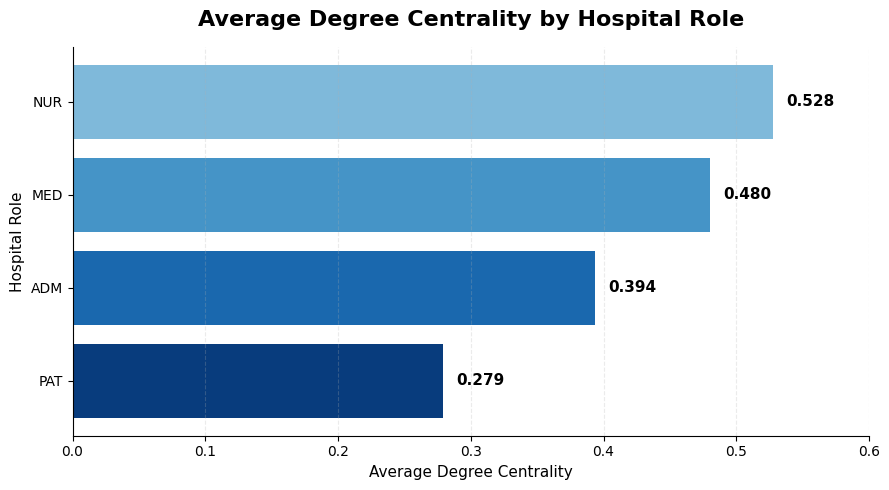

In [ ]:
# Plot average degree centrality by role

# Sort from highest to lowest
role_centrality = role_centrality.sort_values(ascending=False)

colors = plt.cm.Blues(
    np.linspace(0.45, 0.95, len(role_centrality)))

plt.figure(figsize=(9, 5))

bars = plt.barh(
    role_centrality.index,
    role_centrality.values,
    color=colors)

# Put highest value at the top
plt.gca().invert_yaxis()

# Add values to the bars
for bar, value in zip(bars, role_centrality.values):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold")

plt.title(
    "Average Degree Centrality by Hospital Role",
    fontsize=16,
    fontweight="bold",
    pad=15)

plt.xlabel("Average Degree Centrality", fontsize=11)
plt.ylabel("Hospital Role", fontsize=11)
plt.xlim(0, 0.6)
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Comparing degree and eigenvector centrality

The scatter plot compares degree centrality with eigenvector centrality for each individual in the hospital network. Each point represents one person, with color indicating their hospital role. The plot allows us to examine whether individuals with more direct connections also tend to be connected to other highly connected individuals. The generally positive relationship between the two measures is consistent with the earlier results, where the role groups showed similar patterns across both measures.

There seems to be a strong positive relationship between degree centrality and eigenvector centrality. Individuals with higher degree centrality generally also have higher eigenvector centrality. For example, individuals with degree centrality around 0.75–0.80 tend to have eigenvector centrality around 0.18–0.19, while individuals with degree centrality below 0.20 generally have eigenvector centrality below 0.06.

This pattern makes sense because individuals with many direct connections are often also connected to other highly connected individuals. Therefore, they receive high scores on both measures. However, the two measures are not identical. Some individuals with similar degree centrality have slightly different eigenvector centrality values, suggesting that who an individual is connected to matters in addition to how many connections they have.

The plot also shows that the four hospital roles are distributed across much of the network rather than forming completely separate groups. Nurses and medical doctors appear frequently among the individuals with relatively high centrality, while patients are more common among individuals with lower centrality values. Administrative staff appear across the range as well, although there are fewer administrative staff members in the dataset.

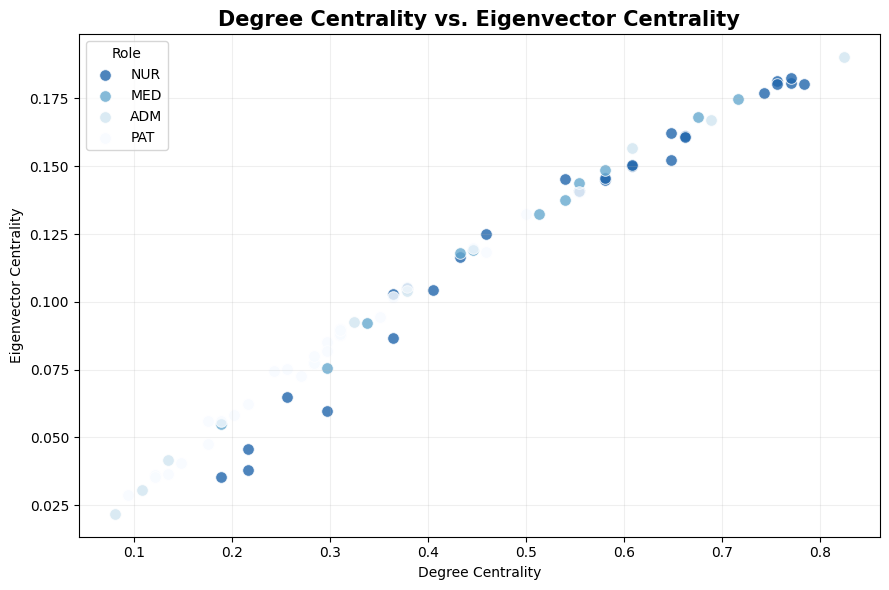

In [ ]:
# Plot degree centrality vs. eigenvector centrality
plt.figure(figsize=(9, 6))

colors = {
    "NUR": "#2166AC",
    "MED": "#67A9CF",
    "ADM": "#D1E5F0",
    "PAT": "#F7FBFF"
}

for role, color in colors.items():
    subset = centrality[centrality["role"] == role]

    plt.scatter(
        subset["degree_centrality"],
        subset["eigenvector_centrality"],
        label=role,
        color=color,
        s=70,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.7)

plt.title(
    "Degree Centrality vs. Eigenvector Centrality",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Degree Centrality")
plt.ylabel("Eigenvector Centrality")
plt.legend(title="Role")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Statistical test: ANOVA of Degree centrality and Tukey HSD post-hoc results

A one-way ANOVA was conducted to determine whether average degree centrality differed across the four hospital roles. The results showed a statistically significant difference between the groups, F(3, 71) = 10.187, p < .001. Therefore, the null hypothesis that all four roles have the same mean degree centrality was rejected. However, ANOVA does not identify which specific groups differ, so a Tukey HSD post-hoc test was conducted.

The Tukey HSD results showed that medical doctors had significantly higher degree centrality than patients (adjusted p = .0091), while nurses also had significantly higher degree centrality than patients (adjusted p < .001). The other pairwise comparisons were not statistically significant, including nurses versus medical doctors (p = .8701), nurses versus administrative staff (p = .2310), and medical doctors versus administrative staff (p = .7084).

The results suggest that the main differences in degree centrality occur between patients and healthcare workers, particularly nurses and medical doctors. Although nurses had the highest average degree centrality, their average was not significantly different from that of medical doctors or administrative staff.

In [ ]:
# ANOVA on degree centrality

# Separate degree centrality by role
nur = centrality[centrality["role"] == "NUR"]["degree_centrality"]
med = centrality[centrality["role"] == "MED"]["degree_centrality"]
adm = centrality[centrality["role"] == "ADM"]["degree_centrality"]
pat = centrality[centrality["role"] == "PAT"]["degree_centrality"]

# Run one-way ANOVA
f_stat, p_value = f_oneway(nur, med, adm, pat)

print("One-way ANOVA: Degree Centrality by Role")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("The differences in degree centrality between roles are statistically significant.")
else:
    print("The differences in degree centrality between roles are not statistically significant.")

# Run Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(
    endog=centrality["degree_centrality"],
    groups=centrality["role"],
    alpha=0.05)

print(tukey)

One-way ANOVA: Degree Centrality by Role
F-statistic: 10.187
p-value: 0.0000
The differences in degree centrality between roles are statistically significant.
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   ADM    MED   0.0868 0.7084 -0.1264     0.3  False
   ADM    NUR   0.1344  0.231 -0.0502  0.3191  False
   ADM    PAT  -0.1145 0.3613 -0.2977  0.0688  False
   MED    NUR   0.0477 0.8701 -0.1164  0.2118  False
   MED    PAT  -0.2012 0.0091 -0.3637 -0.0388   True
   NUR    PAT  -0.2489    0.0 -0.3716 -0.1262   True
----------------------------------------------------


#### Network Graph of Hospital Roles

To visualize the hospital ward contact network, I created an undirected network using NetworkX. Each node represents an individual, and each edge represents a recorded connection between two individuals. Node colors represent hospital roles: nurses (NUR) are dark blue, medical doctors (MED) are light blue, administrative staff (ADM) are green, and patients (PAT) are peach. Node size is based on degree centrality, so individuals with more connections appear as larger nodes.

The visualization shows that the hospital network is highly interconnected, with a dense concentration of connections near the center. Individuals from all four roles appear throughout this central region, suggesting that interactions occurred across different hospital roles rather than being limited to people within the same role.

Several nurses and medical doctors appear as larger nodes in the center, indicating that they had many direct connections. Some administrative staff members and patients also appear relatively central, although many patients have smaller nodes and are positioned toward the outside of the network. This shows that connectivity varies considerably among individuals, even within the same role.

Overall, the network graph provides a visual representation of the centrality patterns found in the analysis. The network contains a highly connected core with individuals from multiple roles, while patients generally appear less connected. Combined with the degree centrality results and ANOVA analysis, the visualization supports the conclusion that hospital role is associated with differences in network connectivity, particularly between patients and healthcare workers.


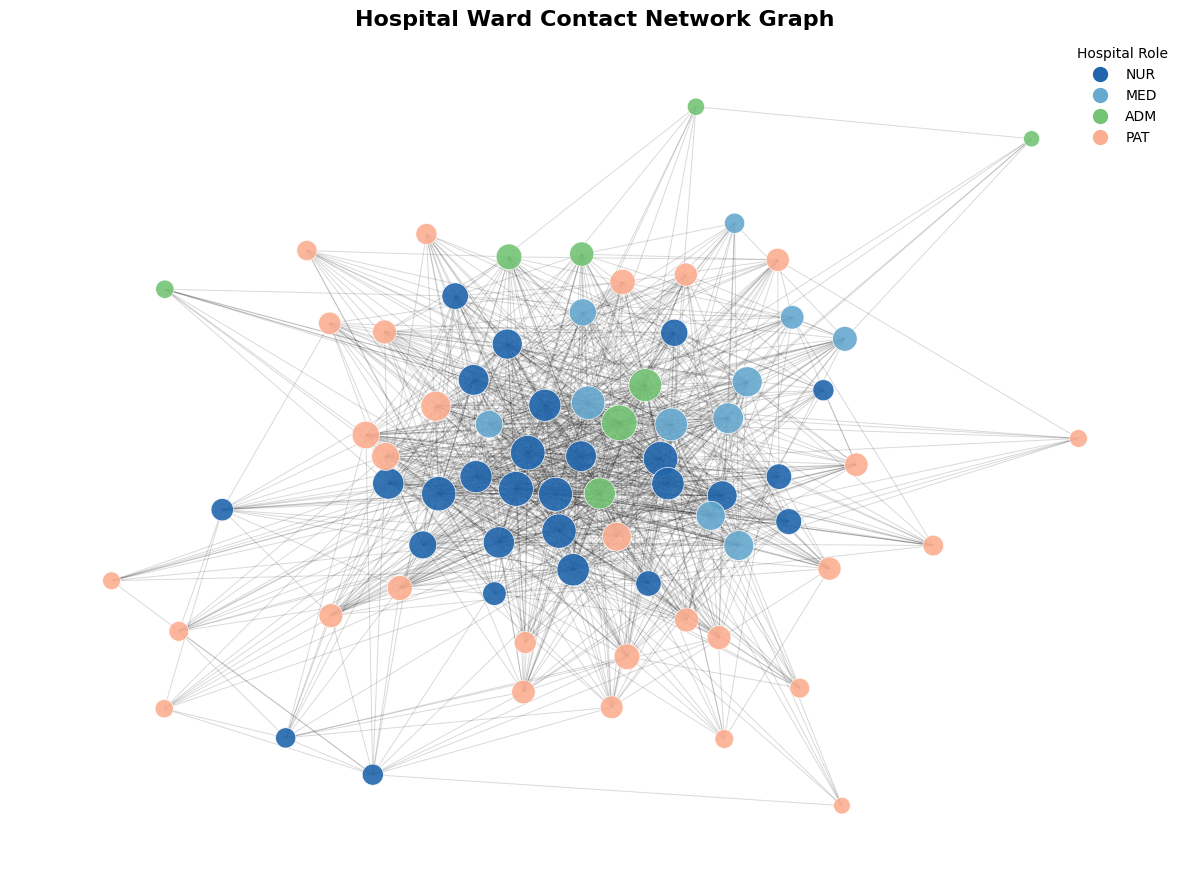

In [ ]:
# Define colors for each hospital role
role_colors = {
    "NUR": "#2166AC",
    "MED": "#67A9CF",
    "ADM": "#74C476",
    "PAT": "#FCAE91"
}

# Get node colors based on role
node_colors = [
    role_colors[G.nodes[node]["role"]]
    for node in G.nodes()
]

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)

# Make node size proportional to degree centrality
# Larger nodes (more direct connections)
node_sizes = [
    80 + 700 * degree_centrality[node]
    for node in G.nodes()
]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15,
    width=0.7
)

# Nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.5
)

# Title
plt.title(
    "Hospital Ward Contact Network Graph",
    fontsize=16,
    fontweight="bold"
)

# Create role legend
for role, color in role_colors.items():
    plt.scatter(
        [],
        [],
        c=color,
        s=100,
        label=role)

plt.legend(
    title="Hospital Role",
    frameon=False)

plt.axis("off")
plt.tight_layout()
plt.show()

#### Conclusions

This project examined whether individuals' roles in a hospital were associated with their positions in a face-to-face contact network. Overall, the results support my hypothesis that connectivity differs across hospital roles. Nurses had the highest average degree centrality (0.528), followed by medical doctors (0.480), administrative staff (0.394), and patients (0.279). The ANOVA confirmed that these differences were statistically significant, and the Tukey HSD test showed that both nurses and medical doctors had significantly higher degree centrality than patients.

The eigenvector centrality results showed a similar pattern. Nurses had the highest average eigenvector centrality (0.129), followed by medical doctors (0.124), administrative staff (0.101), and patients (0.078). This suggests that nurses were not only connected to more people, but were also connected to individuals who tended to be well connected themselves. The network visualization supported these findings by showing nurses and medical doctors frequently occupying larger, more central positions within the network, while many patients appeared toward the outside with fewer connections.

One interesting finding was that administrative staff member 1098 had the highest individual degree and eigenvector centrality scores. This shows that hospital role alone does not determine an individual's position in the network, since some individuals can be much more connected than others within the same role.

Overall, the analysis suggests that hospital role is related to an individual's position within the contact network, with patients generally having fewer connections than healthcare workers. The results also highlight the important role of nurses, who appear to occupy highly connected positions and may serve as important links between different parts of the hospital network. These findings demonstrate how network analysis can reveal patterns of interaction that may not be apparent from simply looking at the roles or characteristics of individuals.